<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/04_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regression and Prediction**

This notebook covers Regression and Prediction:
1. Simple Linear Regression
2. Multiple Linear Regression
3. Prediction Using Regression
4. Factor Variables in Regression
5. Interpreting the Regression Equation
6. Regression Diagnostics
7. Polynomial and Spline Regression
8. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Establishing a standard seed ensures academic reproducibility
np.random.seed(42)

# Fetching datasets directly from the textbook's official public repository
LUNG_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/LungDisease.csv'
HOUSE_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv'

lung = pd.read_csv(LUNG_CSV)
house = pd.read_csv(HOUSE_CSV, sep='\t')

print("Libraries imported and regression datasets successfully loaded into memory.")

Libraries imported and regression datasets successfully loaded into memory.


## **1. Simple Linear Regression**

Simple linear regression models the relationship between two continuous variables: a single predictor variable (often denoted as $X$) and a response variable ($Y$). The core hypothesis is that this relationship can be adequately summarized by a straight line, mathematically expressed as $Y = b_0 + b_1X + e$. Here, $b_0$ represents the intercept (the expected value of $Y$ when $X$ is zero), $b_1$ represents the slope (how much $Y$ changes for a one-unit increase in $X$), and $e$ represents the residual error.

To find the optimal line that best fits the data, statisticians almost universally rely on Ordinary Least Squares (OLS). OLS calculates the coefficients ($b_0$ and $b_1$) that minimize the sum of the squared residual errors—the vertical distances between the actual data points and the predicted line. Squaring the residuals ensures that positive and negative errors do not cancel each other out, and it heavily penalizes large outliers, forcing the line to be as representative of the central mass of data as possible.

Intercept (b0): 424.583
Coefficient for Exposure (b1): -4.185


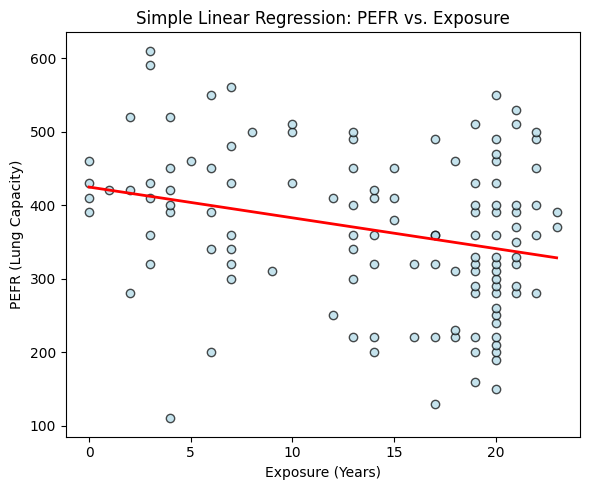

In [2]:
# Implementing Simple Linear Regression using Scikit-Learn
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f"Intercept (b0): {model.intercept_:.3f}")
print(f"Coefficient for Exposure (b1): {model.coef_[0]:.3f}")

# Plotting the regression line against the scatterplot of actual data
plt.figure(figsize=(6, 5))
plt.scatter(lung['Exposure'], lung['PEFR'], color='lightblue', edgecolor='black', alpha=0.7)
plt.plot(lung['Exposure'], model.predict(lung[predictors]), color='red', linewidth=2)
plt.xlabel('Exposure (Years)')
plt.ylabel('PEFR (Lung Capacity)')
plt.title('Simple Linear Regression: PEFR vs. Exposure')
plt.tight_layout()
plt.show()

## **2. Multiple Linear Regression**

Real-world phenomena are rarely driven by a single factor. Multiple Linear Regression expands the simple model to accommodate multiple predictor variables simultaneously ($Y = b_0 + b_1X_1 + b_2X_2 + ... + b_nX_n + e$). This allows the data scientist to isolate the specific effect of one variable while mathematically holding all other variables constant.

Evaluating a multiple regression model requires specific metrics. The Root Mean Squared Error (RMSE) provides an absolute measure of prediction error in the same units as the target variable. Meanwhile, $R^2$ (R-squared) measures the proportion of the total variance in the target variable that is successfully explained by the model. However, relying purely on $R^2$ is dangerous, as adding *any* variable (even useless noise) will artificially inflate the score. Therefore, rigorous analysts utilize the *Adjusted $R^2$*, which fundamentally penalizes the addition of predictor variables that do not genuinely improve the model's predictive power.

In [3]:
# Implementing Multiple Linear Regression on the King County Housing Dataset
subset = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
target = 'AdjSalePrice'

house_subset = house[subset + [target]].dropna()

X = house_subset[subset]
y = house_subset[target]

house_lm = LinearRegression()
house_lm.fit(X, y)

# Calculating Model Evaluation Metrics
fitted = house_lm.predict(X)
RMSE = np.sqrt(mean_squared_error(y, fitted))
r2 = r2_score(y, fitted)

print("Multiple Linear Regression Coefficients:")
for name, coef in zip(subset, house_lm.coef_):
    print(f" {name}: {coef:,.2f}")
print(f"\nRoot Mean Squared Error (RMSE): ${RMSE:,.0f}")
print(f"R-squared (R2): {r2:.4f}")

Multiple Linear Regression Coefficients:
 SqFtTotLiving: 228.83
 SqFtLot: -0.06
 Bathrooms: -19,442.84
 Bedrooms: -47,769.96
 BldgGrade: 106,106.96

Root Mean Squared Error (RMSE): $261,220
R-squared (R2): 0.5406


## **3. Prediction Using Regression**

The primary objective of modern data science is often prediction rather than mere explanation. Once the coefficients are estimated using historical training data, the model can ingest new, unseen data to forecast future outcomes.

However, there is a critical academic caveat here: the danger of Extrapolation. Regression models are only valid within the domain of the data they were trained on. Predicting the sale price of a 5,000 square foot home using a model trained strictly on 1,000 to 2,000 square foot homes is statistically irresponsible, as there is no guarantee the linear relationship holds in that extreme territory. Furthermore, predictions are never perfectly precise. To express uncertainty, we use Prediction Intervals, which provide a plausible range within which an individual future observation will likely fall, incorporating both the uncertainty of the model's coefficients and the inherent variance of the data itself.

## **4. Factor Variables in Regression**

Linear regression mathematics strictly requires numerical inputs. Therefore, categorical features (factor variables)—such as property type, color, or neighborhood—cannot be fed directly into the algorithm. They must be mathematically encoded. The universal standard for this is Dummy Encoding (or One-Hot Encoding).

Dummy encoding transforms a categorical variable with $P$ distinct categories into $P-1$ separate binary columns (containing only 0s and 1s). The crucial academic detail here is the $P-1$ rule, known as 'reference coding'. If a property can only be Single Family, Townhouse, or Multiplex, we only need two binary columns to capture all information. If both are 0, the model implicitly knows it must be the third category (the reference category). Including all $P$ columns would cause perfect multicollinearity, a fatal mathematical error that prevents the OLS matrix inversion process.

In [4]:
# Demonstrating Dummy Encoding (Reference Coding) for 'PropertyType'
house_prop = house[['AdjSalePrice', 'SqFtTotLiving', 'PropertyType']].copy()

# Using pandas get_dummies, drop_first=True strictly enforces the P-1 reference coding rule
house_prop_encoded = pd.get_dummies(house_prop, columns=['PropertyType'], drop_first=True)

print("Original Categorical Data:")
print(house_prop[['PropertyType']].head())
print("\nEncoded Binary Data (Reference coding drops the first category to avoid multicollinearity):")
print(house_prop_encoded.head())

Original Categorical Data:
    PropertyType
1      Multiplex
2  Single Family
3  Single Family
4  Single Family
5  Single Family

Encoded Binary Data (Reference coding drops the first category to avoid multicollinearity):
   AdjSalePrice  SqFtTotLiving  PropertyType_Single Family  \
1      300805.0           2400                       False   
2     1076162.0           3764                        True   
3      761805.0           2060                        True   
4      442065.0           3200                        True   
5      297065.0           1720                        True   

   PropertyType_Townhouse  
1                   False  
2                   False  
3                   False  
4                   False  
5                   False  


## **5. Interpreting the Regression Equation**

Extracting insight from a regression model requires interpreting the coefficients thoughtfully. The naive interpretation is that $b_1$ represents the change in $Y$ given a one-unit change in $X_1$. However, this is only true if the predictor variables are entirely independent.

In reality, variables are often correlated (e.g., Bedrooms and Square Footage). This introduces Multicollinearity, where it becomes mathematically difficult for the model to isolate the individual effect of highly entangled variables, leading to unstable coefficients. Another major academic pitfall is Confounding Variables—an omitted variable that influences both the predictor and the target, falsely causing the model to interpret a spurious correlation as a direct causal relationship. Finally, we must occasionally utilize Interaction Terms ($X_1 \times X_2$). Main effects assume a variable's impact is constant; interaction terms allow the model to recognize that the impact of a variable (like house size) might change depending on another variable (like the specific zip code).

In [5]:
# Demonstrating the impact of correlated variables (Bedrooms and SqFtTotLiving)
corr_matrix = house_subset[['SqFtTotLiving', 'Bedrooms']].corr()
print("Correlation between Predictors:")
print(corr_matrix)

Correlation between Predictors:
               SqFtTotLiving  Bedrooms
SqFtTotLiving       1.000000  0.600317
Bedrooms            0.600317  1.000000


## **6. Regression Diagnostics**

A responsible data scientist never simply fits a model and blindly trusts the output. We must aggressively interrogate the model's assumptions through Regression Diagnostics, which primarily involves analyzing the residuals (the errors).

First, we scan for Outliers (data points far from the predicted line) and Influential Values (outliers possessing high leverage that artificially drag the regression line toward themselves, often measured via Cook's Distance). Secondly, we check for Heteroskedasticity. A core assumption of OLS is homoskedasticity—that the variance of the residuals remains perfectly constant across all predicted values. If a plot of residuals against predicted values shows a cone or funnel shape (where errors grow larger as predictions grow larger), heteroskedasticity is present. This invalidates the model's confidence intervals, meaning our standard errors are untrustworthy and our hypothesis tests are mathematically compromised.

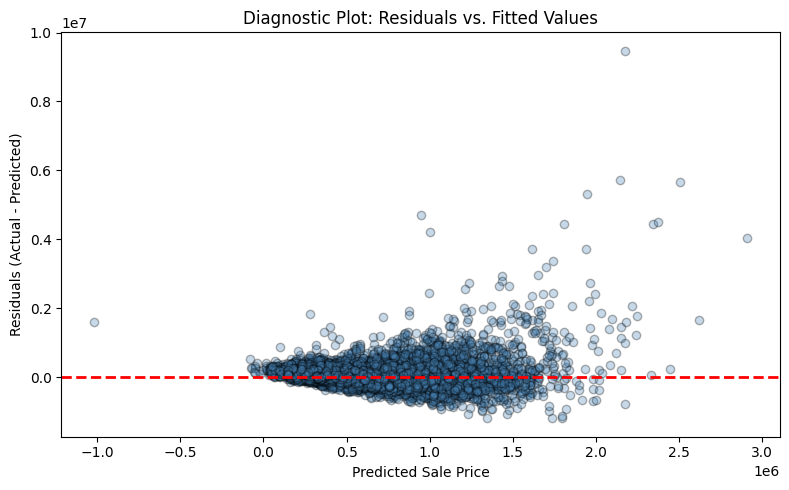

In [6]:
# Performing Regression Diagnostics: Residuals vs Predicted Values
plt.figure(figsize=(8, 5))
residuals = y - fitted
plt.scatter(fitted, residuals, alpha=0.3, color='steelblue', edgecolor='black')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Diagnostic Plot: Residuals vs. Fitted Values')
plt.tight_layout()
plt.show()

## **7. Polynomial and Spline Regression**

Strictly linear lines are often too rigid to capture the complexities of real-world datasets. When the relationship between $X$ and $Y$ features distinct curves, we must upgrade to non-linear models.

Polynomial Regression addresses this by creating new features that represent the variable raised to higher powers ($X^2, X^3$, etc.), allowing the line to curve. However, high-degree polynomials are notoriously unstable and tend to oscillate wildly at the extreme tails of the data. A far more sophisticated academic approach is Spline Regression. Splines divide the x-axis into distinct, localized segments separated by boundaries called 'knots'. Instead of fitting one massive polynomial to the entire dataset, a spline fits multiple smaller, well-behaved polynomials within each specific interval, ensuring they connect smoothly at the knots. This provides immense flexibility without the chaotic oscillations.

In [7]:
# Demonstrating Polynomial Regression using Statsmodels
# We fit a model adding a quadratic term (SqFtTotLiving squared)
model_poly = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2)', data=house_subset)
result_poly = model_poly.fit()
print(result_poly.summary().tables[1])

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3.159e+05   7699.120     41.036      0.000    3.01e+05    3.31e+05
SqFtTotLiving           -24.9680      5.951     -4.196      0.000     -36.632     -13.304
I(SqFtTotLiving ** 2)     0.0584      0.001     56.370      0.000       0.056       0.060


## **8. Summary**

Chapter 4 provides the methodological bridge from merely understanding data to actively predicting it. Linear regression, despite its age and relative simplicity compared to modern deep learning, remains an utterly indispensable tool. Its true power lies not in sheer predictive accuracy, but in its profound interpretability.

Unlike black-box algorithms, a well-constructed regression model allows the data scientist to look under the hood. By analyzing coefficients, assessing factor variables, and rigorously testing residuals for heteroskedasticity, we gain a crystalline understanding of the exact structural relationships driving the data. Furthermore, mastering regression constraints—such as multicollinearity and confounding variables—is an absolute prerequisite before advancing to more complex machine learning models, as these fundamental mathematical pitfalls plague advanced algorithms just as severely as they do basic linear models.